In [1]:
from os import chdir
from pathlib import Path

cwd = Path.cwd()
print(f"CWD: {cwd}")
if cwd.name != "fed-learning":
    chdir("..")
print(f"CWD: {Path.cwd()}")

CWD: /home/james/git/fed-learning/code
CWD: /home/james/git/fed-learning


In [2]:
from src.users import IndependentUser
from src.data_utils import read_in_data
from src.models.BPR import DecBPR
from src.training.bpr_training import (
    TripletDataset, ValidationDatasetIgnoreTraining, decentralized_training_loop, 
    decentralized_validate_loop, DecValidationDataset
)
from src.graphs import create_graph

from tqdm.auto import tqdm
import torch
import numpy as np
import pandas as pd
import seaborn as sns
from torch.optim import SGD
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

In [3]:
train_df_all, test_df = read_in_data("ML100K_100")
train_df, val_df = train_test_split(
    train_df_all, test_size=.2, stratify=train_df_all.user_id
)
n_users, n_items, _ = train_df_all.nunique()

In [4]:
graph = create_graph("fully_connected", n_users)

In [5]:
for i in graph.adj[1]:
    print(i)

0
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [6]:
users = {}
cutoff = 1

batch_size = 5
for user_id in tqdm(range(n_users)):
    u_train = train_df.query("user_id == @user_id")
    u_val = val_df.query("user_id == @user_id")
    u_test = test_df.query("user_id == @user_id")
    # print(u_train.shape, u_val.shape, u_test.shape, pd.concat([u_train, u_val]).sh
    
    train_data = TripletDataset(u_train.to_numpy(), cutoff=cutoff)
    val_data = DecValidationDataset(
        u_train.to_numpy(), u_val.to_numpy(), cutoff=cutoff, n_items=n_items)
    test_data = DecValidationDataset(
#        pd.concat([u_train, u_val]).to_numpy(), u_test.to_numpy(), cutoff=cutoff, n_items=n_items)
        u_train.to_numpy(), u_test.to_numpy(), cutoff=cutoff, n_items=n_items)
    
    # print(user_id)
    # if user_id == 16:
    #     print(u_train)
    #     print(train_data.pos_ui_pairs)
    #     print(train_data.pos_ui_pairs.numel())
    if train_data.pos_ui_pairs.numel() == 0:
        train_dl = DataLoader(train_data, batch_size=batch_size, shuffle=False)
    else: 
        train_dl = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_data, batch_size=1, shuffle=False)
    test_dl = DataLoader(test_data, batch_size=1, shuffle=False)

    
    model = DecBPR(n_items, 10)
    users[user_id] = IndependentUser(
        id=user_id,
        model=model,
        optimizer=SGD(model.parameters(), lr=.01, weight_decay=.001),
        train_dl = train_dl,
        val_dl = val_dl,
        test_dl = test_dl,
        model_name = "DecBPR",
        neighbors = graph.adj[user_id]
    )
    

  0%|          | 0/100 [00:00<?, ?it/s]

In [7]:
val_hr = []
val_ndcg = []

In [8]:
all_hr, all_ndcg = decentralized_validate_loop(users, 10)
hr_mean = all_hr[~np.isnan(all_hr)].mean()
ndcg_mean = all_ndcg[~np.isnan(all_ndcg)].mean()
print(hr_mean, ndcg_mean)

0.008913265923429264 0.0037537161936036486


In [9]:
# decentralized_training_loop(users)

In [18]:
epochs = 500
tbar = tqdm(range(epochs))
for epoch in tbar:
    # print(f"Epoch: {epoch+1}")
    train_loss = decentralized_training_loop(users)
    all_hr, all_ndcg = decentralized_validate_loop(users, 10)
    hr_mean = all_hr[~np.isnan(all_hr)].mean()
    ndcg_mean = all_ndcg[~np.isnan(all_ndcg)].mean()
    val_hr.append(hr_mean)
    val_ndcg.append(ndcg_mean)
    tbar.set_description(f"Epoch: {epoch+1}\tHR: {hr_mean:.03f}\tNDCG: {ndcg_mean:.03f}")

  0%|          | 0/500 [00:00<?, ?it/s]

In [19]:
all_hr, all_ndcg = decentralized_validate_loop(users, 10)

/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

<Axes: >

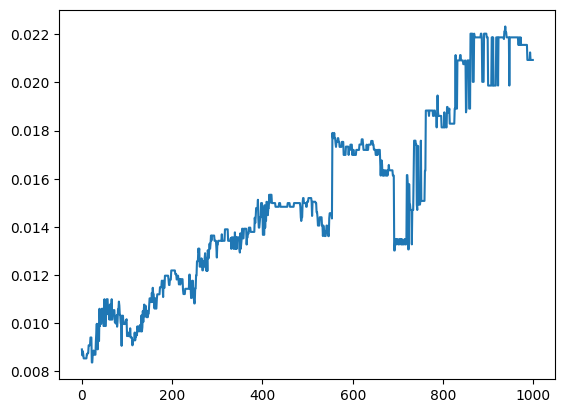

In [20]:
sns.lineplot(val_hr)

/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/james/git/fed-learning/.venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

<Axes: >

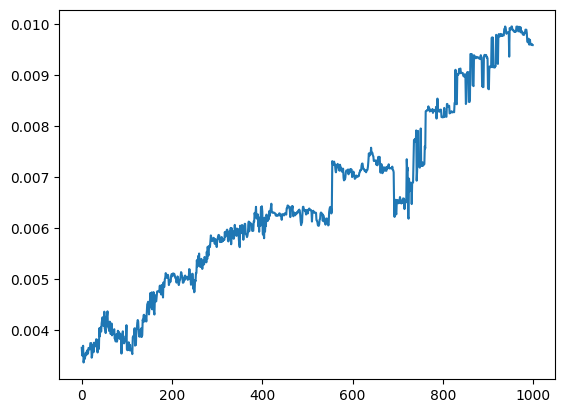

In [21]:
sns.lineplot(val_ndcg)

In [14]:
np.where(np.isnan(all_hr))

(array([], dtype=int64),)

In [15]:
all_hr[~np.isnan(all_hr)].mean()

0.01504220775240109

In [16]:
next(iter(users[19].val_dl))

[tensor([[   1,    2,    4,  ..., 1162, 1163, 1164]]),
 tensor([[ 44, 469, 446, 402,  31, 806, 567, 125, 289, 614, 167, 260, 432, 183]])]

In [17]:
for idx, (u, i, true_pos) in enumerate(users[1].val_dl):
    print(u, i, true_pos)

ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
users[0].train_dl

In [ ]:
for u, i, j in users[0].train_dl:
    print(u, i, j)

In [ ]:
for u, i, j in users[0].train_dl:
    print(u, i, j)
    break

In [ ]:
iter_dl = iter(users[0].train_dl)

In [ ]:
next(iter_dl)

In [ ]:
for u, items_to_rank, true_pos in users[0].val_dl:
    print(u, items_to_rank, true_pos)

In [ ]:
for u, items_to_rank, true_pos in users[0].test_dl:
    print(u, items_to_rank, true_pos)